In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

def lineout(array, w1, w2):
    width = np.shape(array)[0]
    length = np.shape(array)[1]
    line_data = array[w2,:]
    for i in range(length):
        line_data[i] = (1/(w2+1-w1))*np.sum(array[w1:w2+1,i])
    return line_data

def find_index(axis,start,end):
    for i in range(len(axis)):
        if np.abs(axis[i]-start) == np.min(np.abs(axis-start)):
            start_i = i

    for i in range(len(axis)):
        if np.abs(axis[i]-end) == np.min(np.abs(axis-end)):
            end_i = i
    return start_i, end_i

def find_exp_shift(E, A, a, shift):
    func = (A*np.exp(-a*E))+shift
    return func

def find_poly(E, A, a, shift):
    func = (A*E)**a+shift
    return func

coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)
poly_fit_MS = np.poly1d(coefficients)

/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_981/473661478.py:33: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(np.array([0, 125, 250, 375, 500, 717, 789]), np.array([0, 0, 0, 0, 0, 0.0204, 0.0784]), 8)


items in the base directory: [('ATTRIBUTES', <HDF5 group "/ATTRIBUTES" (6 members)>), ('METADATA_CATEGORIES', <HDF5 group "/METADATA_CATEGORIES" (2 members)>), ('PEDIGREE', <HDF5 group "/PEDIGREE" (2 members)>), ('URN', <HDF5 dataset "URN": shape (1,), type "|S61">)]
items in the ATTRIBUTES directory: [('FADE_CORRECTION_TIME', <HDF5 dataset "FADE_CORRECTION_TIME": shape (1,), type "<f8">), ('FADE_CORRECTION_TIME_UOM', <HDF5 dataset "FADE_CORRECTION_TIME_UOM": shape (1,), type "|S7">), ('FADE_TIME', <HDF5 dataset "FADE_TIME": shape (1,), type "<f8">), ('FADE_TIME_UOM', <HDF5 dataset "FADE_TIME_UOM": shape (1,), type "|S1">), ('PSL_FADE_CORR_IMAGE', <HDF5 group "/ATTRIBUTES/PSL_FADE_CORR_IMAGE" (1 members)>), ('PSL_IMAGE', <HDF5 group "/ATTRIBUTES/PSL_IMAGE" (1 members)>)]
items in the PSL_FADE_CORR_IMAGE directory: [('DATA', <HDF5 group "/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA" (6 members)>)]
items in the DATA directory: [('DATA', <HDF5 dataset "DATA": shape (3009, 2977), type "<f4">), ('D

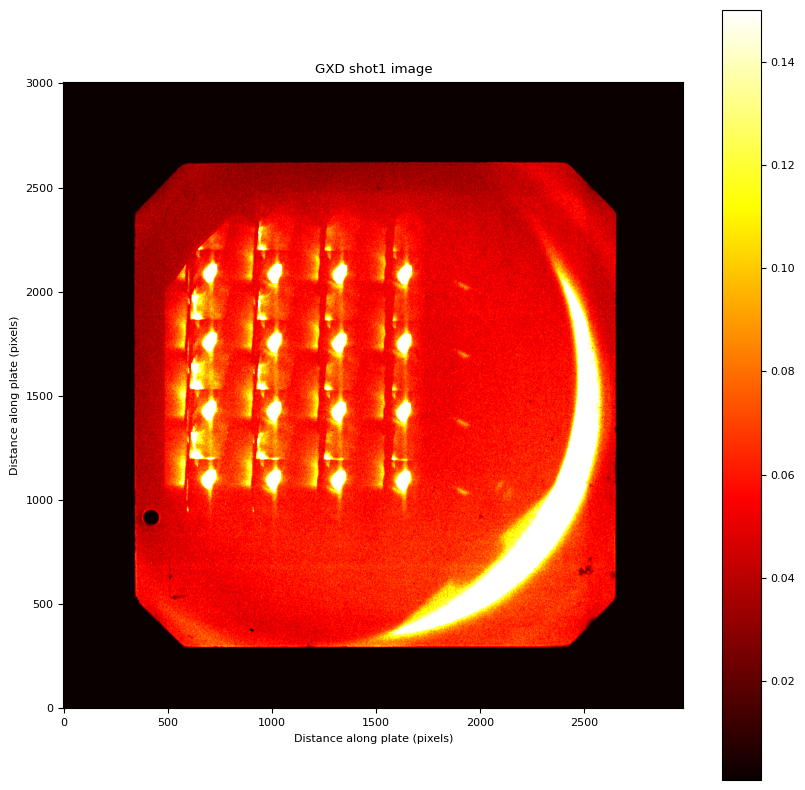

In [9]:
import h5py
import numpy as np

with h5py.File('TD_TC090-078_HGXD_IMAGE-PLATE-2_SCAN-A_IP-CORRECTIONS_N260628-002-999.h5', "r") as f:

    base_items = list(f.items())
    print('items in the base directory:', base_items)

    attributes = f.get('/ATTRIBUTES')
    attributes_list = list(attributes.items())
    print('items in the ATTRIBUTES directory:', attributes_list)

    image_file = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE')
    image_file_list = list(image_file.items())
    print('items in the PSL_FADE_CORR_IMAGE directory:', image_file_list)

    data_file = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA')
    data_file_list = list(data_file.items())
    print('items in the DATA directory:', data_file_list)

    shot_data = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA/DATA')
    shot_data = np.array(shot_data)
    #print(type(shot_data))

    x_axis = f.get('/DATA/X_AXIS')
    x_axis = np.array(x_axis)
    print(type(x_axis))

    y_axis = f.get('/DATA/Y_AXIS')
    y_axis = np.array(y_axis)
    print(type(y_axis))

    import matplotlib.pyplot as plt

    #plt.imshow(shot_data)
    extent = (np.min(x_axis),np.max(x_axis),np.min(y_axis),np.max(y_axis))
    
    fig, axs = plt.subplots(1, 1, figsize=(10, 10))

    plt.rc('font', size=8)

    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+10), vmin = 9.8, cmap='hot', origin='lower')
    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    im1 = axs.imshow(np.log(shot_data+1), vmax = 0.15, cmap='hot', origin='lower')

    axs.set_xlabel('Distance along plate (pixels)')
    axs.set_ylabel('Distance along plate (pixels)')
    axs.set_title('GXD shot1 image')

    plt.colorbar(im1, ax=axs, label='')

NEPPS_1_29= shot_data
x_1_29_axis = x_axis


items in the base directory: [('ATTRIBUTES', <HDF5 group "/ATTRIBUTES" (6 members)>), ('METADATA_CATEGORIES', <HDF5 group "/METADATA_CATEGORIES" (2 members)>), ('PEDIGREE', <HDF5 group "/PEDIGREE" (2 members)>), ('URN', <HDF5 dataset "URN": shape (1,), type "|S61">)]
items in the ATTRIBUTES directory: [('FADE_CORRECTION_TIME', <HDF5 dataset "FADE_CORRECTION_TIME": shape (1,), type "<f8">), ('FADE_CORRECTION_TIME_UOM', <HDF5 dataset "FADE_CORRECTION_TIME_UOM": shape (1,), type "|S7">), ('FADE_TIME', <HDF5 dataset "FADE_TIME": shape (1,), type "<f8">), ('FADE_TIME_UOM', <HDF5 dataset "FADE_TIME_UOM": shape (1,), type "|S1">), ('PSL_FADE_CORR_IMAGE', <HDF5 group "/ATTRIBUTES/PSL_FADE_CORR_IMAGE" (1 members)>), ('PSL_IMAGE', <HDF5 group "/ATTRIBUTES/PSL_IMAGE" (1 members)>)]
items in the PSL_FADE_CORR_IMAGE directory: [('DATA', <HDF5 group "/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA" (6 members)>)]
items in the DATA directory: [('DATA', <HDF5 dataset "DATA": shape (3009, 2977), type "<f4">), ('D

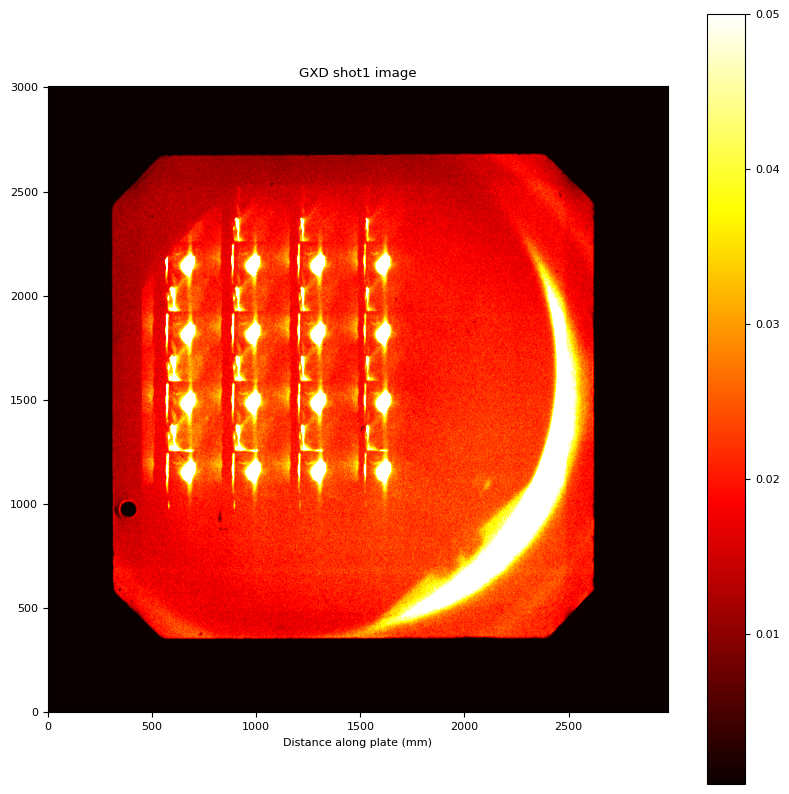

In [11]:
import h5py
import numpy as np

with h5py.File('TD_TC090-078_HGXD_IMAGE-PLATE-2_SCAN-A_IP-CORRECTIONS_N260630-001-999.h5', "r") as f:

    base_items = list(f.items())
    print('items in the base directory:', base_items)

    attributes = f.get('/ATTRIBUTES')
    attributes_list = list(attributes.items())
    print('items in the ATTRIBUTES directory:', attributes_list)

    image_file = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE')
    image_file_list = list(image_file.items())
    print('items in the PSL_FADE_CORR_IMAGE directory:', image_file_list)

    data_file = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA')
    data_file_list = list(data_file.items())
    print('items in the DATA directory:', data_file_list)

    shot_data = f.get('/ATTRIBUTES/PSL_FADE_CORR_IMAGE/DATA/DATA')
    shot_data = np.array(shot_data)
    #print(type(shot_data))

    x_axis = f.get('/DATA/X_AXIS')
    x_axis = np.array(x_axis)
    print(type(x_axis))

    y_axis = f.get('/DATA/Y_AXIS')
    y_axis = np.array(y_axis)
    print(type(y_axis))

    import matplotlib.pyplot as plt

    #plt.imshow(shot_data)
    extent = (np.min(x_axis),np.max(x_axis),np.min(y_axis),np.max(y_axis))
    
    fig, axs = plt.subplots(1, 1, figsize=(10, 10))

    plt.rc('font', size=8)

    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+10), vmin = 9.8, cmap='hot', origin='lower')
    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    im1 = axs.imshow(np.log(shot_data+1), vmax = 0.05, cmap='hot', origin='lower')

    axs.set_xlabel('Distance along plate (mm)')
    axs.set_title('GXD shot1 image')

    plt.colorbar(im1, ax=axs, label='')

NEPPS_1_29= shot_data
x_1_29_axis = x_axis


items in the base directory: [('ATTRIBUTES', <HDF5 group "/ATTRIBUTES" (16 members)>), ('METADATA_CATEGORIES', <HDF5 group "/METADATA_CATEGORIES" (1 members)>), ('URN', <HDF5 dataset "URN": shape (1,), type "|S61">)]
items in the ATTRIBUTES directory: [('ATTENUATION_CCD', <HDF5 dataset "ATTENUATION_CCD": shape (1,), type "<i8">), ('BINNING', <HDF5 dataset "BINNING": shape (1,), type "|S3">), ('CAMERA_TEMPERATURE_WF', <HDF5 group "/ATTRIBUTES/CAMERA_TEMPERATURE_WF" (1 members)>), ('DSI_SAMPLE_DTTM', <HDF5 dataset "DSI_SAMPLE_DTTM": shape (1,), type "<i8">), ('DSI_SAMPLE_DTTM_UOM', <HDF5 dataset "DSI_SAMPLE_DTTM_UOM": shape (1,), type "|S11">), ('INPUT_SLIT_WIDTH', <HDF5 dataset "INPUT_SLIT_WIDTH": shape (1,), type "<f8">), ('INPUT_SLIT_WIDTH_UOM', <HDF5 dataset "INPUT_SLIT_WIDTH_UOM": shape (1,), type "|S2">), ('PRESHOT_IMAGESPRESHOT_IMAGES', <HDF5 group "/ATTRIBUTES/PRESHOT_IMAGESPRESHOT_IMAGES" (1 members)>), ('PRESHOT_IMAGES_DTTM', <HDF5 dataset "PRESHOT_IMAGES_DTTM": shape (1,), typ

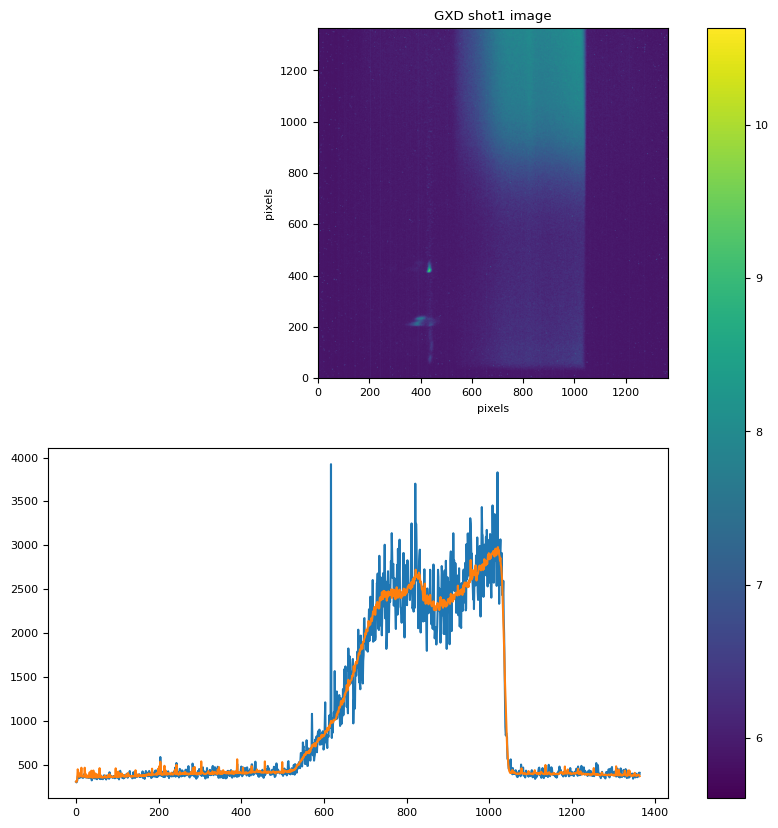

In [23]:
import h5py
import numpy as np

with h5py.File('TD_TC090-315_OTS_STREAK-CCD-01-DB_SHOT_RAW-STREAK-CAMERA_N260628-002-999.h5', "r") as f:

    base_items = list(f.items())
    print('items in the base directory:', base_items)

    attributes = f.get('/ATTRIBUTES')
    attributes_list = list(attributes.items())
    print('items in the ATTRIBUTES directory:', attributes_list)

    image_file = f.get('/ATTRIBUTES/SHOT_IMAGE')
    image_file_list = list(image_file.items())
    print('items in the SHOT_IMAGE directory:', image_file_list)

    data_file = f.get('/ATTRIBUTES/SHOT_IMAGE/DATA')
    data_file_list = list(data_file.items())
    print('items in the DATA directory:', data_file_list)

    shot_data = f.get('/ATTRIBUTES/SHOT_IMAGE/DATA/DATA')
    shot_data = np.array(shot_data)
    #print(type(shot_data))

    x_axis = f.get('/ATTRIBUTES/SHOT_IMAGE/DATA/X_AXIS')
    x_axis = np.array(x_axis)
    print(type(x_axis))

    y_axis = f.get('/ATTRIBUTES/SHOT_IMAGE/DATA/Y_AXIS')
    y_axis = np.array(y_axis)
    print(type(y_axis))

    import matplotlib.pyplot as plt

    #plt.imshow(shot_data)
    extent = (np.min(x_axis),np.max(x_axis),np.min(y_axis),np.max(y_axis))
    
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    plt.rc('font', size=8)

    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+10), vmin = 9.8, cmap='hot', origin='lower')
    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+1), cmap='hot', origin='lower')
    im1 = axs[0].imshow(np.log(shot_data+1), origin='lower')

    axs[0].set_xlabel('pixels')
    axs[0].set_ylabel('pixels')
    axs[0].set_title('GXD shot1 image')

    plt.colorbar(im1, ax=axs, label='')

OTS_002_999= shot_data
x_002_999_axis = x_axis
y_002_999_axis = y_axis

axs[1].plot(x_axis,shot_data[1200,:])
axs[1].plot(x_axis,lineout(shot_data,1150,1250))

items in the base directory: [('ATTRIBUTES', <HDF5 group "/ATTRIBUTES" (6 members)>), ('METADATA_CATEGORIES', <HDF5 group "/METADATA_CATEGORIES" (2 members)>), ('PEDIGREE', <HDF5 group "/PEDIGREE" (3 members)>), ('URN', <HDF5 dataset "URN": shape (1,), type "|S61">)]
items in the ATTRIBUTES directory: [('EPW_CORR_IMAGE_GRAPH', <HDF5 group "/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH" (1 members)>), ('EPW_VALID_WAVLEN_AXIS_1', <HDF5 dataset "EPW_VALID_WAVLEN_AXIS_1": shape (1,), type "<f8">), ('EPW_VALID_WAVLEN_AXIS_2', <HDF5 dataset "EPW_VALID_WAVLEN_AXIS_2": shape (1,), type "<f8">), ('IAW_CORR_IMAGE_GRAPH', <HDF5 group "/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH" (1 members)>), ('IAW_VALID_WAVLEN_AXIS_1', <HDF5 dataset "IAW_VALID_WAVLEN_AXIS_1": shape (1,), type "<f8">), ('IAW_VALID_WAVLEN_AXIS_2', <HDF5 dataset "IAW_VALID_WAVLEN_AXIS_2": shape (1,), type "<f8">)]
items in the EPW_CORR_IMAGE_GRAPH directory: [('DATA', <HDF5 group "/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH/DATA" (9 members)>)]
items in the DATA di

/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_981/1195876903.py:127: RuntimeWarning: divide by zero encountered in divide
  axs[2].plot(x_axis,lineout(shot_data,lineout_mid_1-50,lineout_mid_1+50)/lineout(shot_data,lineout_mid_3-50,lineout_mid_3+50))
/var/folders/mn/__zk_6j559bcx6_fgpwgw61m0000gn/T/ipykernel_981/1195876903.py:127: RuntimeWarning: invalid value encountered in divide
  axs[2].plot(x_axis,lineout(shot_data,lineout_mid_1-50,lineout_mid_1+50)/lineout(shot_data,lineout_mid_3-50,lineout_mid_3+50))


(0.0, 20.0)

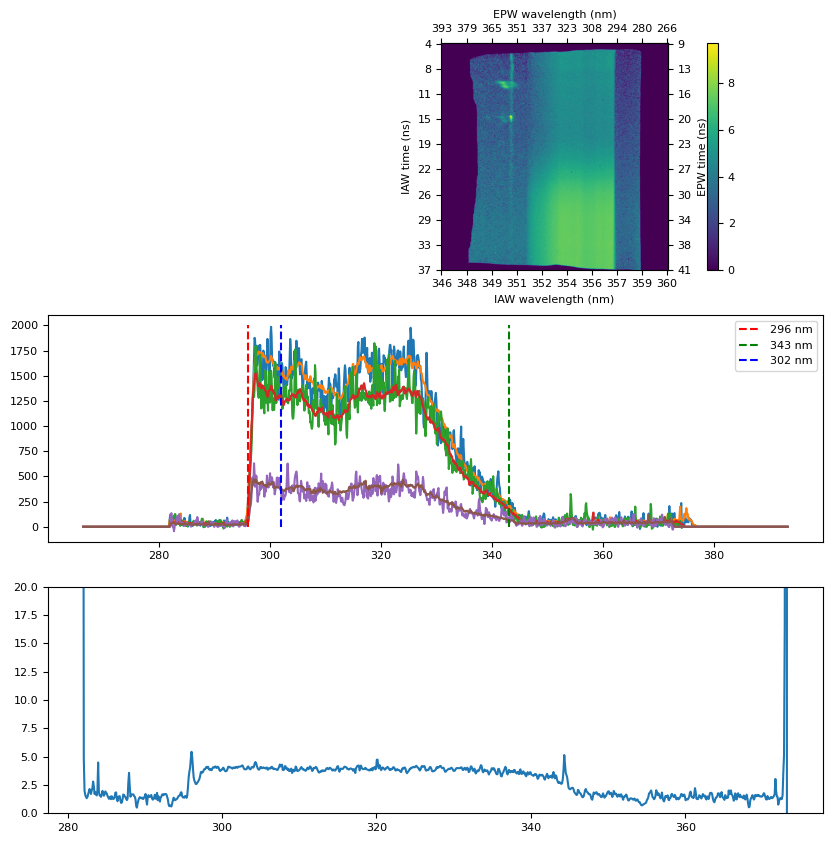

In [59]:
import h5py
import numpy as np
import math

with h5py.File('TD_TC090-315_OTS_STREAK-CCD-01-DB_SHOT_CALIB-AXES_N260628-002-999.h5', "r") as f:

    base_items = list(f.items())
    print('items in the base directory:', base_items)

    attributes = f.get('/ATTRIBUTES')
    attributes_list = list(attributes.items())
    print('items in the ATTRIBUTES directory:', attributes_list)

    image_file = f.get('/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH')
    image_file_list = list(image_file.items())
    print('items in the EPW_CORR_IMAGE_GRAPH directory:', image_file_list)

    data_file = f.get('/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH/DATA')
    data_file_list = list(data_file.items())
    print('items in the DATA directory:', data_file_list)

    shot_data = f.get('/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH/DATA/DATA')
    shot_data = np.array(shot_data)
    #print(type(shot_data))

    x_axis = f.get('/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH/DATA/X_AXIS')
    x_axis = np.array(x_axis)
    print(type(x_axis))

    y_axis = f.get('/ATTRIBUTES/EPW_CORR_IMAGE_GRAPH/DATA/Y_AXIS')
    y_axis = np.array(y_axis)
    print(type(y_axis))

    image_file = f.get('/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH')
    image_file_list = list(image_file.items())
    print('items in the IAW_CORR_IMAGE_GRAPH directory:', image_file_list)

    data_file = f.get('/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH/DATA')
    data_file_list = list(data_file.items())
    print('items in the DATA directory:', data_file_list)

    shot_data_IAW = f.get('/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH/DATA/DATA')
    shot_data_IAW = np.array(shot_data_IAW)
    #print(type(shot_data))

    x_axis_IAW = f.get('/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH/DATA/X_AXIS')
    x_axis_IAW = np.array(x_axis_IAW)
    print(type(x_axis))

    y_axis_IAW = f.get('/ATTRIBUTES/IAW_CORR_IMAGE_GRAPH/DATA/Y_AXIS')
    y_axis_IAW = np.array(y_axis_IAW)
    print(type(y_axis))

    import matplotlib.pyplot as plt

    #plt.imshow(shot_data)
    extent = (np.min(x_axis),np.max(x_axis),np.min(y_axis),np.max(y_axis))
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    plt.rc('font', size=8)
    
    tick_loc = np.linspace(0,len(x_axis)-1,len(x_axis))
    tick_loc_y = np.linspace(0,len(y_axis)-1,len(y_axis))

    #shot_data = shot_data_IAW

    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+10), vmin = 9.8, cmap='hot', origin='lower')
    #im1 = axs.imshow(shot_data, cmap='hot', origin='lower')
    #im1 = axs.imshow(np.log(shot_data+1), cmap='hot', origin='lower')
    sdata = np.zeros(np.shape(shot_data))
    for i in range(np.shape(shot_data)[0]):
        for j in range(np.shape(shot_data)[1]):
            if shot_data[i,j] > 0:
                sdata[i,j] = shot_data[i,j]

    #im1 = axs[0].imshow(sdata, origin='lower')
    im1 = axs[0].imshow(np.log(sdata+1), origin='lower')

    axs[0].set_xlabel('IAW wavelength (nm)')
    axs[0].set_xticks(tick_loc[::151], labels = [int(i) for i in x_axis_IAW[::151]])

    axs[0].set_ylabel('IAW time (ns)')
    axs[0].set_yticks(tick_loc[::151], labels = [int(i) for i in y_axis_IAW[::151]])

    #axs[0].set_xticks(tick_loc[::151], labels = [int(i) for i in x_axis[::151]])
    #axs[0].set_title('')

    plt.colorbar(im1, ax=axs[0], label='')

    ax0 = axs[0].secondary_xaxis('top')
    ax0.set_xticks(tick_loc[::151], labels = [int(i) for i in x_axis[::151]])

    axy = axs[0].secondary_yaxis('right')
    axy.set_yticks(tick_loc_y[::151], labels = [int(i) for i in y_axis[::151]])
    axy.set_ylabel('EPW time (ns)')
    
    ax0.set_xlabel('EPW wavelength (nm)')


OTS_002_999= shot_data
x_002_999_axis = x_axis
y_002_999_axis = y_axis

lineout_mid_1 = 200
lineout_mid_2 = 400
lineout_mid_3 = 600



axs[1].plot(x_axis,shot_data[lineout_mid_1,:])
axs[1].plot(x_axis,lineout(shot_data,lineout_mid_1-50,lineout_mid_1+50))

axs[1].plot(x_axis,shot_data[lineout_mid_2,:])
axs[1].plot(x_axis,lineout(shot_data,lineout_mid_2-50,lineout_mid_2+50))

axs[1].plot(x_axis,shot_data[lineout_mid_3,:])
axs[1].plot(x_axis,lineout(shot_data,lineout_mid_3-50,lineout_mid_3+50))

axs[1].plot([296,296],[0,2000],linestyle = '--',color = 'red', label = '296 nm')
axs[1].plot([343,343],[0,2000],linestyle = '--',color = 'green', label = '343 nm')
axs[1].plot([302,302],[0,2000],linestyle = '--',color = 'blue', label = '302 nm')

axs[1].legend()

axs[2].plot(x_axis,lineout(shot_data,lineout_mid_1-50,lineout_mid_1+50)/lineout(shot_data,lineout_mid_3-50,lineout_mid_3+50))
axs[2].set_ylim(0,20)
